## **Business Understanding**

#### **Latar Belakang**
Penyakit jantung merupakan salah satu penyebab kematian tertinggi di dunia menurut World Health Organization. Salah satu indikator pending dalam diagnosis penyakit jantung adalah tingkat penyempitan pembuluh darah.

Namun, proses diagnosis seringkali membutuhkan pemeriksaan lanjutan yang tidak selalu cepat atau murah. Oleh karena itu, diperlukan pendekatan berbasis data untuk membantu memprediksi risiko penyakit jantung secara lebih dini menggunakan parameter yang tersedia.

#### **Tujuan**
1. Mengembangkan model klasifikasi untuk memprediksi variabel target 'num'.
2. Melakukan perbandingan beberapa algoritma machine learning, yaitu Regresi Logistik, Decision Tree, Random Forest, SVM, dan KNN.
3. Menentukan model terbaik berdasarkan performa evaluasi.

#### **Definisi Target**
Variabel target yang digunakan adalah 'num' dengan keterangan sebagai berikut:
1. '0' --> penyempitan pembuluh darah < 50%.
2. '1' --> penyempitan pembuluh darah > 50%.
Sehingga, permasalahan ini termasuk dalam binary classification.

#### **Business Objective**
1. Membantu tenaga medis dalam melakukan screening awal.
2. Mengidentifikasi pasien berisiko tinggi secara lebih cepat.
3. Mendukung pengambilan keputusan berbasis data.

#### **Manfaat**
1. Bagi Medis
   - Deteksi dini penyakit jantung
   - Mengurangi keterlambatan diagnosis
   - Membantu prioritas penanganan pasien
2. Bagi Pasien
   - Mendapatkan peringatan risiko lebih awal
   - Meningkatkan peluang pencegahan

#### **Metode Evaluasi**
1. Accuracy
2. Precision
3. Recall
4. F1-Score
5. Confusion Matrix
Dalam permasalahan ini, Recall untuk kelas positif (num = 1) menjadi fokus utama. Hal ini karena kesalahan dalam mendeteksi pasien yang benar-benar sakit (false negative) dapat berdampak serius.

## **Data Understanding**

#### **Impor Data**

In [1]:
import pandas as pd
data = 'data (1).csv'
data = pd.read_csv(data)
data.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [2]:
data.rename(columns={'num       ' : 'num'}, inplace=True)

#### **Karakteristik Dari Setiap Variabel Pada Dataset**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  294 non-null    object 
 4   chol      294 non-null    object 
 5   fbs       294 non-null    object 
 6   restecg   294 non-null    object 
 7   thalach   294 non-null    object 
 8   exang     294 non-null    object 
 9   oldpeak   294 non-null    float64
 10  slope     294 non-null    object 
 11  ca        294 non-null    object 
 12  thal      294 non-null    object 
 13  num       294 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 32.3+ KB


Dari informasi di atas, dapat diketahui beberapa informasi sebagai berikut:
1. Dimensi Dataset
    - Dimensi dataset adalah (294, 14) yang berarti dataset terdiri dari 294 baris dan 14 kolom.
2. Tipe Data
    - Terdapat 4 variabel yang memiliki tipe data berupa integer, yaitu age, sex, cp, dan num.
    - Terdapat 1 variabel yang memiliki tipe data berupa float, yaitu old peak.
    - Terdapat 9 variabel yang memiliki tipe data berupa object, yaitu trestbps, chol, fbs, restecg, thalach, exang, slope, ca, dan thal.
3. Definisi Setiap Variabel
    - age: usia pasien dalam tahun
    - sex: jenis kelamin pasien (1 = male; 0 = female)
    - cp: chest pain type (1 = typical angina; 2 = atypical angina; 3 = nonanginal pain; 4 = asymptomatic)
    - trestbps: resting blood pressure (in mm Hg)
    - chol: serum cholesterol (in mg/dl)
    - fbs: fasting blood sugar > 120mg/dl (1 = true; 0 = false)
    - restecg: resting electrocardiographic results (0 = normal; 1 = having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of 0.05 mV); 2 = showing probable or definite left ventricular hypertrophy by Ester' criteria / menunjukkan kemungkinan atau kepastian hipertrofi ventrikular kiri menurut kriteria Ester)
    - thalach: maximum heart rate achieved / maksimum detak jantung yg bisa diraih
    - exang: exercise induces angina/angina yg dipicu atau disebabkan oleh olahraga (1 = yes; 0 = no)
    - oldpeak: ST depression induced by exercise relative to rest/penurunan segmen ST pada EKG saat olahraga dibandingkan saat istirahat
    - slope: the slope of the peak exercise ST segment/kemiringan segmen ST puncak latihan (1 = upsloping; 2 = flat; 3 = downsloping)
    - ca: number of major vessels (0--3) colored by fluoroscopy/jumlah pembuluh darah utama yang diwarnai oleh fluoroskopi
    - thal: 3 = normal; 6 = fixed defect/cacat tetap; 7 = reversable defect/cacat yang dapat dibalik
    - num: diagnosis of heart disease (angiographic disease status --> 0 = <50% diameter narrowing; 1 = >50% diameter narrowing)

#### **Pemeriksaan Imbalanced Class**

In [4]:
counts = data['num'].value_counts()
print(counts)

num
0    188
1    106
Name: count, dtype: int64


In [5]:
persentase = round(counts / len(data['num']), 2)
print(persentase)

num
0    0.64
1    0.36
Name: count, dtype: float64


Berdasarkan distribusi target di atas, didapatkan proporsi kelas 0 sebesar 64% dan kelas 1 sebesar 36%. Hal ini menunjukkan adanya ketidakseimbangan kelas dalam tingkat yang tergolong ringan. Namun, perbedaan proporsi tersebut tidak terlalu signifikan sehingga tidak diperlukan teknik balancing data.



## **Data Preparation**

#### **Pengubahan Tipe Data**

In [6]:
print(data.dtypes)

age           int64
sex           int64
cp            int64
trestbps     object
chol         object
fbs          object
restecg      object
thalach      object
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
num           int64
dtype: object


In [16]:
data_prep = data.copy()

In [17]:
data_prep.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [18]:
data_prep.dtypes

age           int64
sex           int64
cp            int64
trestbps     object
chol         object
fbs          object
restecg      object
thalach      object
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
num           int64
dtype: object

Tahap pertama dari Data Preparation adalah Pengubahan Tipe Data. Hal ini penting dilakukan karena adanya nilai nonnumerik, yaitu simbol "?" yang menyebabkan beberapa variabel terbaca sebagai objek.

Di sini, tahap pengubahan atau convert dibagi menjadi dua, yaitu convert objek ke numerik dan convert kategorikal ke integer.
1. Convert Objek ke Numerik
   - Tipe convert ini mengubah tipe data dari kolom yang bersifat kuantitatif menjadi numerik (float).
   - Kolom yang akan dilakukan convert menggunakan tipe ini adalah trestbps, chol, dan thalach.
2. Convert Kategorikal ke Integer
   - Tipe convert ini mengubah tipe data dari kolom kategorikal menjadi tipe integer.
   - Kolom yang akan dilakukan convert menggunakan tipe ini adalah fbs, restecg, exang, slope, ca, dan thal.

In [19]:
#convert objek ke numerik
cols_numeric = ['trestbps', 'chol', 'thalach']
for col in cols_numeric:
  # error='coerce' akan mengubah nilai yang tidak bisa dikonversi menjadi NaN
  data_prep[col] = pd.to_numeric(data_prep[col], errors='coerce')

#convert kategorikal ke int
cols_categorikal = ['age', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in cols_categorikal:
  data_prep[col] = pd.to_numeric(data_prep[col], errors='coerce').astype('Int64')

In [20]:
print(data_prep.dtypes)

age           Int64
sex           Int64
cp            Int64
trestbps    float64
chol        float64
fbs           Int64
restecg       Int64
thalach     float64
exang         Int64
oldpeak     float64
slope         Int64
ca            Int64
thal          Int64
num           int64
dtype: object


#### **Pemeriksaan Missing Value**

In [21]:
data_prep.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130.0,132.0,0,2,185.0,0,0.0,<NA>,<NA>,<NA>,0
1,29,1,2,120.0,243.0,0,0,160.0,0,0.0,<NA>,<NA>,<NA>,0
2,29,1,2,140.0,NaN,0,0,170.0,0,0.0,<NA>,<NA>,<NA>,0
3,30,0,1,170.0,237.0,0,1,170.0,0,0.0,<NA>,<NA>,6,0
4,31,0,2,100.0,219.0,0,1,150.0,0,0.0,<NA>,<NA>,<NA>,0
5,32,0,2,105.0,198.0,0,0,165.0,0,0.0,<NA>,<NA>,<NA>,0
6,32,1,2,110.0,225.0,0,0,184.0,0,0.0,<NA>,<NA>,<NA>,0
7,32,1,2,125.0,254.0,0,0,155.0,0,0.0,<NA>,<NA>,<NA>,0
8,33,1,3,120.0,298.0,0,0,185.0,0,0.0,<NA>,<NA>,<NA>,0
9,34,0,2,130.0,161.0,0,0,190.0,0,0.0,<NA>,<NA>,<NA>,0


In [22]:
data_prep.isnull().sum()

age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64

In [34]:
persen_question = round(data_prep.isnull().sum() / len(data_prep) * 100, 2)
persen_missing = persen_question[persen_question > 0]
persen_missing

trestbps     0.34
chol         7.82
fbs          2.72
restecg      0.34
thalach      0.34
exang        0.34
slope       64.63
ca          98.98
thal        90.48
dtype: float64

Dari hasil di atas, terdapat 3 kategori missing values:
1. Missing Value Rendah < 5%
   - terdapat 4 kolom yang termasuk dalam kategori ini, yaitu trestbps 0.34%, fbs 2.72%, restecg 0.34%, thalach 0.34%, dan exang 0.34%.
   - penangangan pada kategori ini adalah drop row karena kehilangan data sangat kecil dan tidak akan merusak distribusi.  
2. Missing Value Sedang 5% - 50%
   - terdapat 1 kolom yang termasuk dalam kategori ini, yaitu chol 7.82%.
   - penanganan pada kategori ini adalah imputasi karena jika dilakukan drop row maka data akan berkurang cukup besar.
3. Missing Value Tinggi > 50%
   - terdapat 3 kolom yang termasuk dalam kategori ini, yaitu slope 64.63%, thal 90.48%, dan ca 98.98%.
   - penanganan pada kategori ini adalah drop column karena variabel dengan missing > 50% tidak memberikan kontribusi signifikan pada model dan lebih baik dihapus.

Urutan penanganan missing value dimulai dari Missing Value Tinggi, lalu Missing Value Sedang, dan terakhir Missing Value Rendah.

##### **Penangangan Missing Value Tinggi (slope, thal, ca)**

In [35]:
data_prep = data_prep.drop(columns=['slope', 'thal', 'ca'])

Penangangan Missing Value Tinggi dilakukan dengan cara melakukan drop column slope, thal, dan ca menggunakan fungsi drop(columns=).

##### **Penanganan Missing Value Sedang (chol)**

In [37]:
# Penanganan Missing Value Sedang (chol)
data_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    Int64  
 1   sex       294 non-null    Int64  
 2   cp        294 non-null    Int64  
 3   trestbps  293 non-null    float64
 4   chol      271 non-null    float64
 5   fbs       286 non-null    Int64  
 6   restecg   293 non-null    Int64  
 7   thalach   293 non-null    float64
 8   exang     293 non-null    Int64  
 9   oldpeak   294 non-null    float64
 10  num       294 non-null    int64  
dtypes: Int64(6), float64(4), int64(1)
memory usage: 27.1 KB


In [38]:
chol_clean = data_prep['chol'].dropna()

q1 = chol_clean.quantile(0.25)
q3 = chol_clean.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = chol_clean[(chol_clean < lower_bound) | (chol_clean > upper_bound)]

print("Nilai lower bound:", lower_bound)
print("Nilai upper bound:", upper_bound)
print("Jumlah outliers:", len(outliers))

Nilai lower bound: 98.75
Nilai upper bound: 392.75
Jumlah outliers: 11


Dari hasil di atas dapat diketahui bahwa terdapat 11 outlier. Karena terdapat outlier, maka metode imputasi yang baik untuk digunakan adalah imputasi median. Hal ini karena median robust terhadap outlier dibandingkan mean.  

In [42]:
data_prep['chol'] = data_prep['chol'].fillna(data_prep['chol'].median())

In [66]:
print(data_prep['chol'].isna().sum())

0


##### **Penanganan Missing Value Rendah (trestbps, fbs, restecg, thalach, dan exang)**

In [67]:
data_prep = data_prep.dropna(subset=['trestbps', 'fbs', 'restecg', 'thalach', 'exang'])

In [68]:
data_prep.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
num         0
dtype: int64

Dari hasil di atas dapat diketahui bahwa seluruh missing value telah berhasil diatasi.

#### **Pemeriksaan Duplicate Value**

In [65]:
data_prep.duplicated().sum()

np.int64(0)

In [ ]:
# keep=False akan menandai semua baris yang duplikat, termasuk yang pertama kali muncul
# jika first, hanya baris pertama, jika last, hanya baris terakhir yang akan dianggap duplikat
duplicate_row = data_prep[data_prep.duplicated(keep=False)]
print(duplicate_row)

     age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  num
101   49    0   2     110.0  243.0    0        0    160.0      0      0.0    0
102   49    0   2     110.0  243.0    0        0    160.0      0      0.0    0


Dari hasil di atas terlihat bahwa terdapat duplicated values pada baris 101 dan 102 sehingga perlu dilakukan penanganan berupa drop salah satunya.

In [56]:
data_prep.drop_duplicates(inplace=True)

In [57]:
data_prep.duplicated().sum()

np.int64(0)

Dari hasil di atas dapat terlihat bahwa sudah tidak terdapat duplicated value.

In [69]:
data_prep.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
num         0
dtype: int64

In [70]:
data_prep.head(50)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130.0,132.0,0,2,185.0,0,0.0,0
1,29,1,2,120.0,243.0,0,0,160.0,0,0.0,0
2,29,1,2,140.0,243.0,0,0,170.0,0,0.0,0
3,30,0,1,170.0,237.0,0,1,170.0,0,0.0,0
4,31,0,2,100.0,219.0,0,1,150.0,0,0.0,0
5,32,0,2,105.0,198.0,0,0,165.0,0,0.0,0
6,32,1,2,110.0,225.0,0,0,184.0,0,0.0,0
7,32,1,2,125.0,254.0,0,0,155.0,0,0.0,0
8,33,1,3,120.0,298.0,0,0,185.0,0,0.0,0
9,34,0,2,130.0,161.0,0,0,190.0,0,0.0,0


#### **One Hot Encoding**

Selanjutnya, langkah terakhir pada tahap Data Preparation adalah melakukan encoding terhadap variabel `cp` dan `restecg`. Teknik encoding yang digunakan adalah One Hot Encoding karena kedua tidak memiliki hubungan ordinal antar kategorinya. Jadi, setiap kategori direpresentasikan sebagai variabel biner yang terpisah agar dapat diolah dengan baik oleh model machine learning.

Selain kedua variabel tersebut, sebenarnya variabel `thal` juga dapat diperlakukan sebagai variabel nominal dan dilalkukan One Hot Encoding. Begitu juga dengan variabel `slope`. Lalu, variabel `ca` juga dapat dipertahankan sebagai numerik karena merepresentasikan jumlah pembuluh darah utama. Namun, karena kedua variabel ini sudah dihapus karena cleaning yang telah dilakukan sebelumnya, jadi tidak dapat dipertahankan serta dilakukan one hot encoding. 

Sementara itu, variabel `sex`, `fbs`, dan `exang` telah berbentuk variabel biner sehingga tidak memerlukan encoding tambahan. 

In [73]:
data_encoding = pd.get_dummies(data_prep, columns=['cp','restecg'], drop_first=True)

In [74]:
data_encoding.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,num,cp_2,cp_3,cp_4,restecg_1,restecg_2
0,28,1,130.0,132.0,0,185.0,0,0.0,0,True,False,False,False,True
1,29,1,120.0,243.0,0,160.0,0,0.0,0,True,False,False,False,False
2,29,1,140.0,243.0,0,170.0,0,0.0,0,True,False,False,False,False
3,30,0,170.0,237.0,0,170.0,0,0.0,0,False,False,False,True,False
4,31,0,100.0,219.0,0,150.0,0,0.0,0,True,False,False,True,False


In [75]:
data_encoding.columns

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak',
       'num', 'cp_2', 'cp_3', 'cp_4', 'restecg_1', 'restecg_2'],
      dtype='object')

## **Modeling**

#### **Split Data**

In [81]:
from sklearn.model_selection import train_test_split

x = data_encoding.drop('num', axis=1)
y = data_encoding['num']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

Langkah pertama dalam tahap modeling adalah melakukan split data menjadi dua bagian, yaitu data training dan data testing. Data training mencakup seluruh variabel kecuali variabel 'num'. Sementara itu, data testing hanya mencakup variabel 'num' saja.

Proporsi antara data training dan data testing menggunakan perbandingan 80% : 20% dengan penggunaan stratify = y agar seimbang antara kelas 0 dan kelas 1.

#### **Scaling**

In [84]:
print(type(x_train))
print(type(x_test))
print(x_train.shape)
print(x_test.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
(226, 13)
(57, 13)


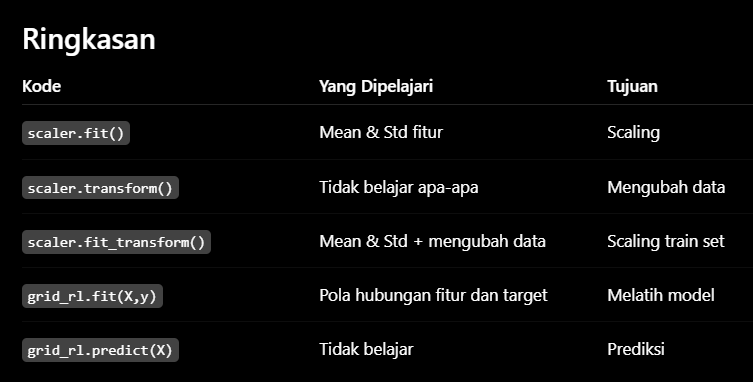

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Melakukan scaling pada data fitur latih dan data fitur uji
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Scaling diperlukan dalam model Regresi Logistik, SVM dan KNN. 
- Regresi Logistik menggunakan scaling karena proses optimasi (mencari bobot terbaik dengan meminimalkan error pakai iterasi (gradient descent)) akan lebih cepat dan stabil ketiak fitur memiliki skala yg beragam.
- SVM perlu scaling agar pembentukan margin dan hyperplane tidak didominasi oleh fitur tertentu
- KNN membutuhkan scaling karena proses klasifikasi dilakukan berdasarkan perhitungan jarak antardata. 
 

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

#### **Regresi Logistik**

In [95]:
from sklearn.linear_model import LogisticRegression

pipe_rl = Pipeline([
    ('scaler', scaler),
    ('model', LogisticRegression(max_iter=1000))
])

param_rl = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

grid_rl = GridSearchCV(pipe_rl, param_rl, cv=5, scoring='recall')
grid_rl.fit(x_train_scaled, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


#### **Decision Tree**

In [123]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])

param_dt = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1,2,4], 
    'model__class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(pipe_dt, param_dt, cv=5, scoring='recall')
grid_dt.fit(x_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__class_weight': [None, 'balanced'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


#### **Random Forest**

In [124]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2], 
    'model__class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(pipe_rf, param_rf, cv=5, scoring='recall')
grid_rf.fit(x_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__class_weight': [None, 'balanced'], 'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


#### **Support Vector Machine (SVM)**

In [99]:
from sklearn.svm import SVC

pipe_svm = Pipeline ([
    ('scaler', scaler),
    ('model', SVC())
])

param_svm = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(pipe_svm, param_svm, cv=5, scoring='recall')
grid_svm.fit(x_train_scaled, y_train)


,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['linear', 'rbf']}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


#### **K-Nearest Neighbor (KNN)**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ('scaler', scaler),
    ('model', KNeighborsClassifier())
])

param_knn = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(pipe_knn, param_knn, cv=5, scoring='recall')
grid_knn.fit(x_train_scaled, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


## **Evaluation**

In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}

models = {
    'Regresi Logistik': grid_rl,
    'Decision Tree': grid_dt,
    'Random Forest': grid_rf,
    'SVM': grid_svm,
    'KNN': grid_knn
}

scaled_models = ['Regresi Logistik', 'SVM', 'KNN']

# for name, model in models.items():
# name adalah nama model, model adalah hasil GridSearchCV untuk model tersebut
for name, model in models.items():
  best_model = model.best_estimator_
  if name in scaled_models:
    y_pred = best_model.predict(x_test_scaled)
  else:
    y_pred = best_model.predict(x_test)
  results[name] = {
    'Best Parameters': model.best_params_,
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred)
  }

hasil = pd.DataFrame(results).T
hasil

,Best Parameters,accuracy,precision,recall,f1_score
Regresi Logistik,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.842105,0.875,0.666667,0.756757
Decision Tree,"{'model__class_weight': 'balanced', 'model__ma...",0.754386,0.62069,0.857143,0.72
Random Forest,"{'model__class_weight': 'balanced', 'model__ma...",0.842105,0.833333,0.714286,0.769231
SVM,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.824561,0.866667,0.619048,0.722222
KNN,"{'model__metric': 'euclidean', 'model__n_neigh...",0.789474,0.846154,0.52381,0.647059


--> Dari hasil di atas, dapat diketahui bahwa model terbaik adalah Decision Tree karena memiliki skor recall tertinggi, yaitu 85.71%. Hal ini menunjukkan bahwa model berhasil mengenali sekitar 85.71% pasien yang benar-benar memiliki penyempitan pembuluh darah signifikan (>50%), yaitu pasien dengan label 1, yakni terindikasi penyakit jantung.

--> Dengan kata lain, model masih belum berhasil mendeteksi seluruh pasien berisiko karena sekitar 14.29% pasien dengan kondisi penyempitan pembuluh darah >50% tidak dikenali oleh model (false negative).

--> Meskipun precision tergolong terendah, yakni hanya 0.62, tetapi salah mendeteksi pasien sehat sebagai sakit (False Positive) tidak lebih berbahaya daripada salah mendeteksi pasien sakit sebagai sehat (False Negative)


#### **Feature Importance**

In [126]:
# feature importance decision tree
best_dt = grid_dt.best_estimator_.named_steps['model']
feature_importance_dt = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(
    by='Importance', 
    ascending=False)

print(feature_importance_dt)


      Feature  Importance
6       exang    0.522709
10       cp_4    0.169712
5     thalach    0.133728
7     oldpeak    0.060962
0         age    0.036174
8        cp_2    0.026789
1         sex    0.025252
2    trestbps    0.024674
3        chol    0.000000
4         fbs    0.000000
9        cp_3    0.000000
11  restecg_1    0.000000
12  restecg_2    0.000000


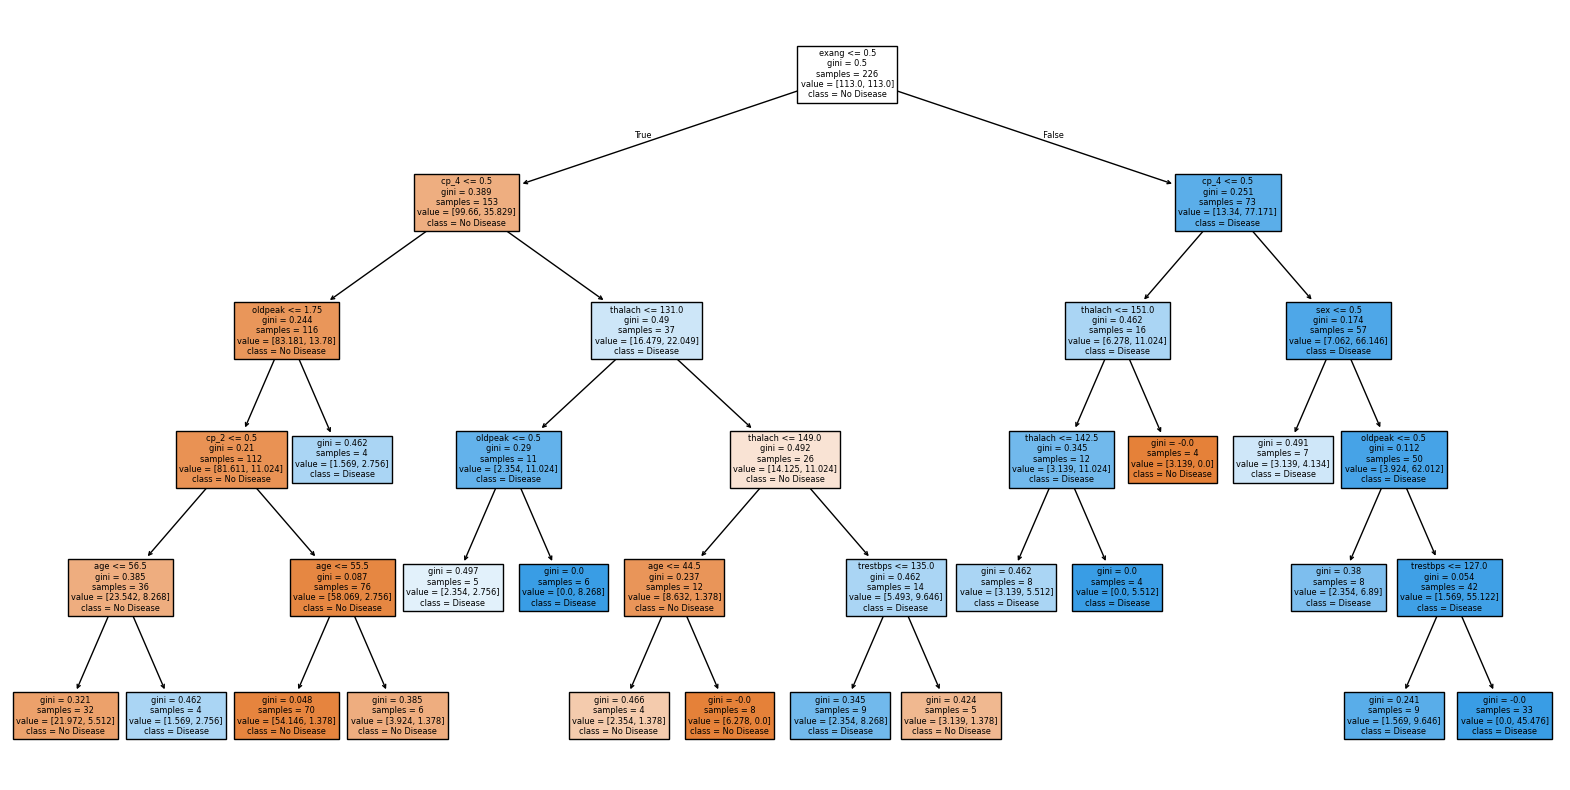

In [127]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt 

plt.figure(figsize=(20,10))

plot_tree(
    best_dt, 
    feature_names=x_train.columns, 
    class_names=['No Disease', 'Disease'], 
    filled=True
)
plt.show()

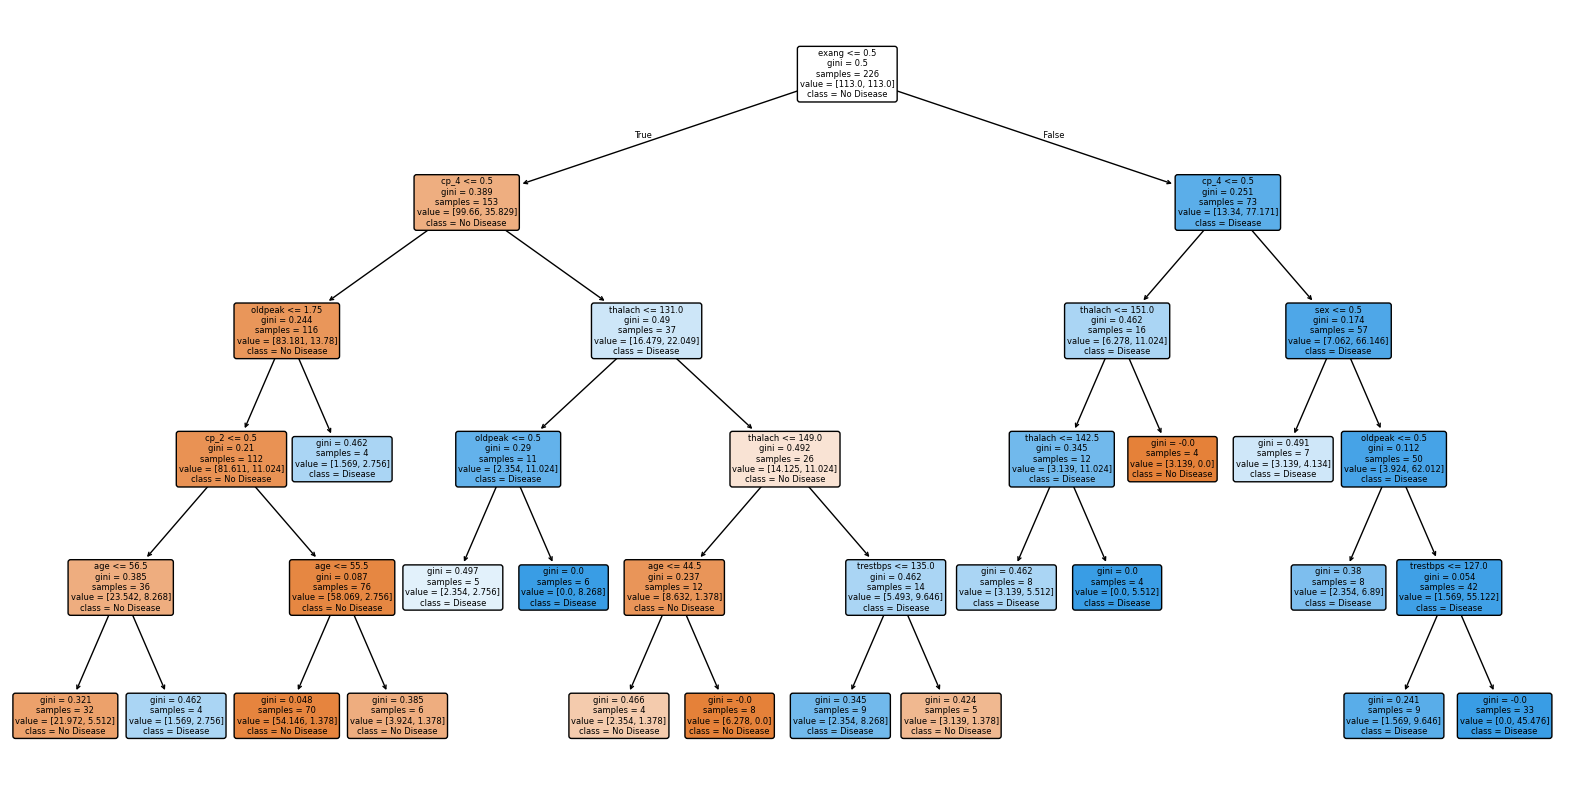

FEATURE IMPORTANCE SKLEARN
age             : 0.036174
sex             : 0.025252
trestbps        : 0.024674
chol            : 0.000000
fbs             : 0.000000
thalach         : 0.133728
exang           : 0.522709
oldpeak         : 0.060962
cp_2            : 0.026789
cp_3            : 0.000000
cp_4            : 0.169712
restecg_1       : 0.000000
restecg_2       : 0.000000


INFO TREE
Jumlah Node : 35
Jumlah Feature : 13


PERHITUNGAN NODE

NODE 0
Feature      : exang
Samples      : 226
Gini Parent  : 0.500000
Gini Left    : 0.389027
Gini Right   : 0.251330
Contribution : 0.155450

NODE 1
Feature      : cp_4
Samples      : 153
Gini Parent  : 0.389027
Gini Left    : 0.243849
Gini Right   : 0.489551
Contribution : 0.058058

NODE 2
Feature      : oldpeak
Samples      : 116
Gini Parent  : 0.243849
Gini Left    : 0.209691
Gini Right   : 0.462370
Contribution : 0.013061

NODE 3
Feature      : cp_2
Samples      : 112
Gini Parent  : 0.209691
Gini Left    : 0.384731
Gini Right   : 0.086517
Co

In [128]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# ====================================================
# VISUALISASI TREE
# ====================================================

plt.figure(figsize=(20,10))

plot_tree(
    best_dt,
    feature_names=x_train.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True
)

plt.show()

# ====================================================
# FEATURE IMPORTANCE SKLEARN
# ====================================================

print("="*60)
print("FEATURE IMPORTANCE SKLEARN")
print("="*60)

for feature, importance in zip(
    x_train.columns,
    best_dt.feature_importances_
):
    print(f"{feature:<15} : {importance:.6f}")

# ====================================================
# AMBIL STRUKTUR TREE
# ====================================================

tree = best_dt.tree_

feature_names = x_train.columns.tolist()

n_nodes = tree.node_count

print("\n")
print("="*60)
print("INFO TREE")
print("="*60)

print("Jumlah Node :", n_nodes)
print("Jumlah Feature :", len(feature_names))

# ====================================================
# HITUNG MANUAL IMPURITY DECREASE
# ====================================================

total_samples = tree.n_node_samples[0]

manual_importance = np.zeros(len(feature_names))

print("\n")
print("="*60)
print("PERHITUNGAN NODE")
print("="*60)

for node in range(n_nodes):

    feature_idx = tree.feature[node]

    # leaf node
    if feature_idx == -2:
        continue

    left_child = tree.children_left[node]
    right_child = tree.children_right[node]

    N_t = tree.n_node_samples[node]
    N_l = tree.n_node_samples[left_child]
    N_r = tree.n_node_samples[right_child]

    gini_parent = tree.impurity[node]
    gini_left = tree.impurity[left_child]
    gini_right = tree.impurity[right_child]

    weighted_decrease = (
        (N_t / total_samples)
        * (
            gini_parent
            - (N_l / N_t) * gini_left
            - (N_r / N_t) * gini_right
        )
    )

    manual_importance[feature_idx] += weighted_decrease

    print(f"\nNODE {node}")
    print(f"Feature      : {feature_names[feature_idx]}")
    print(f"Samples      : {N_t}")
    print(f"Gini Parent  : {gini_parent:.6f}")
    print(f"Gini Left    : {gini_left:.6f}")
    print(f"Gini Right   : {gini_right:.6f}")
    print(f"Contribution : {weighted_decrease:.6f}")

# ====================================================
# RAW IMPORTANCE
# ====================================================

print("\n")
print("="*60)
print("RAW IMPORTANCE (SEBELUM NORMALISASI)")
print("="*60)

raw_df = pd.DataFrame({
    "Feature": feature_names,
    "Raw_Importance": manual_importance
})

raw_df = raw_df.sort_values(
    by="Raw_Importance",
    ascending=False
)

print(raw_df)

# ====================================================
# NORMALISASI
# ====================================================

manual_importance_normalized = (
    manual_importance /
    manual_importance.sum()
)

# ====================================================
# HASIL AKHIR MANUAL
# ====================================================

print("\n")
print("="*60)
print("FEATURE IMPORTANCE MANUAL")
print("="*60)

manual_df = pd.DataFrame({
    "Feature": feature_names,
    "Manual_Importance":
        manual_importance_normalized
})

manual_df = manual_df.sort_values(
    by="Manual_Importance",
    ascending=False
)

print(manual_df)

# ====================================================
# BANDINGKAN DENGAN SKLEARN
# ====================================================

print("\n")
print("="*60)
print("PERBANDINGAN MANUAL VS SKLEARN")
print("="*60)

comparison = pd.DataFrame({
    "Feature": feature_names,
    "Manual":
        manual_importance_normalized,
    "Sklearn":
        best_dt.feature_importances_
})

comparison["Difference"] = (
    comparison["Manual"]
    - comparison["Sklearn"]
)

comparison = comparison.sort_values(
    by="Manual",
    ascending=False
)

print(comparison)

# ====================================================
# KHUSUS FEATURE EXANG
# ====================================================

if "exang" in feature_names:

    idx = feature_names.index("exang")

    print("\n")
    print("="*60)
    print("DETAIL FEATURE EXANG")
    print("="*60)

    print(
        "Raw Contribution :",
        round(manual_importance[idx], 6)
    )

    print(
        "Normalized Importance :",
        round(
            manual_importance_normalized[idx],
            6
        )
    )

    print(
        "Sklearn Importance :",
        round(
            best_dt.feature_importances_[idx],
            6
        )
    )

Dari output di atas, cara menghitung feature importance, misal exang, adalah sebagai berikut. 
- Gain Exang = 0.1555973 (ada di Node 0)
- Gain Total = 0.155973 + 0.029758 + 0.006278 + 0.012042 + 0.012939 + 0.011799 + 0.012077 = 0.2404903

Feature Importance Exang = 0.1555973 / 0.2404903 = 0.647

#### **Classification Report**

In [134]:
from sklearn.metrics import classification_report

y_pred_dt = best_dt.predict(x_test_scaled)

report_dt = classification_report(y_test, y_pred_dt)
print("Classification Report - Decision Tree:\n")
print(report_dt)

Classification Report - Decision Tree:

              precision    recall  f1-score   support

           0       0.90      0.75      0.82        36
           1       0.67      0.86      0.75        21

    accuracy                           0.79        57
   macro avg       0.78      0.80      0.78        57
weighted avg       0.81      0.79      0.79        57



c:\Users\Luzar Dwain Ruszardi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


--> Nilai accuracy, precision, recall, f1-score, dan support di atas berbeda hasilnya dengan yang dihasilkan oleh yang sebelumnya karena sebelumnya menggunakan GridSearchCV dimana data berasal dari banyak fold (CV), sedangkan pada classification report data hanya berasal dari 1 test split saja.

--> Pada classification report di atas terlihat bahwa kelas 1 atau pasien dengan penyempitan pembuluh darah > 50% sebanyak 21 orang, sedangkan kelas 0 atau pasien dengan penyempitan pembuluh darah < 50% sebanyak 36 orang.

--> Nilai recall yang cukup tinggi, yakni sebesar 92% menunjukkan bahwa model berhasil mengenali pasien dengan penyempitan pembuluh darah > 50% dengan nyaris sempurna dimana hanya 8% pasien saja yang tidak dikenali oleh model.  

## **Uji Coba Data Baru**

In [131]:
import pandas as pd

user_data = pd.DataFrame([{
    "age": 55,
    "sex": 1,
    "cp": 3,
    "trestbps": 140,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.2,
    "slope": 2,
    "ca": 1,
    "thal": 3
}])

user_encoded = pd.get_dummies(user_data).reindex(columns=x.columns, fill_value=0) #semua kolom training wajib ada, yang tidak ada akan diisi 0

prediction = best_dt.predict(user_encoded)
print("Hasil prediksi:", prediction)

Hasil prediksi: [0]


In [132]:
import pandas as pd

user_data = pd.DataFrame([{
    "age": 55,
    "sex": 1,
    "cp": 3,
    "trestbps": 140,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 1,
    "oldpeak": 2.5,
    "slope": 2,
    "ca": 1,
    "thal": 3
}])

user_encoded = pd.get_dummies(user_data).reindex(columns=x.columns, fill_value=0)

prediction = best_dt.predict(user_encoded)
print("Hasil prediksi:", prediction)

Hasil prediksi: [1]


Dari dua hasil uji coba di atas dapat dilihat bahwa exang memengaruhi risiko penyakit jantung seseorang. Jika sebelumnya pasien yang tidak mengalami angina diprediksi tidak berisiko terkena penyakit jantung, maka pasien yang mengalami angina diprediksi terkena penyakit jantung.